In [ ]:
!pip install openslide-bin
!apt install openslide-tools
import openslide

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openslide-tools is already the newest version (3.4.1+dfsg-5build1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


In [ ]:
from openslide import open_slide

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import tifffile as tiff

In [ ]:
from PIL import Image

In [ ]:

wsi = open_slide("/content/CMU-1-Small-Region.svs")

# Printing out the properties of the WSI
wsi_props = wsi.properties
wsi_props

<_PropertyMap {'aperio.AppMag': '20', 'aperio.Date': '12/29/09', 'aperio.Filename': 'CMU-1', 'aperio.Filtered': '5', 'aperio.Focus Offset': '0.000000', 'aperio.ImageID': '1004486', 'aperio.Left': '25.691574', 'aperio.LineAreaXOffset': '0.019265', 'aperio.LineAreaYOffset': '-0.000313', 'aperio.LineCameraSkew': '-0.000424', 'aperio.MPP': '0.4990', 'aperio.OriginalHeight': '32914', 'aperio.OriginalWidth': '46000', 'aperio.Originalheight': '33014', 'aperio.Parmset': 'USM Filter', 'aperio.ScanScope ID': 'CPAPERIOCS', 'aperio.StripeWidth': '2040', 'aperio.Time': '09:59:15', 'aperio.Top': '23.449873', 'aperio.User': 'b414003d-95c6-48b0-9369-8010ed517ba7', 'openslide.associated.label.height': '463', 'openslide.associated.label.width': '387', 'openslide.associated.macro.height': '431', 'openslide.associated.macro.width': '1280', 'openslide.associated.thumbnail.height': '768', 'openslide.associated.thumbnail.width': '574', 'openslide.comment': 'Aperio Image Library v11.2.1 \r\n46000x32914 [42673

In [ ]:
# Printing out associated images
wsi_assc_images = wsi.associated_images.items()

wsi_assc_images

ItemsView(<_AssociatedImageMap {'label': <PIL.Image.Image image mode=RGBA size=387x463 at 0x78143B58B7D0>, 'macro': <PIL.Image.Image image mode=RGBA size=1280x431 at 0x78143A4F71D0>, 'thumbnail': <PIL.Image.Image image mode=RGBA size=574x768 at 0x78143A4F73D0>}>)

In [ ]:
# Printing out the WSI scanner vendor
wsi_props['openslide.vendor']



'aperio'

In [ ]:
wsi_props['openslide.mpp-x']
wsi_props['openslide.mpp-y']

'0.499'

In [ ]:
Objective = float(wsi.properties[openslide.PROPERTY_NAME_OBJECTIVE_POWER])
Objective

20.0

In [ ]:
# Getting the WSI pixel dimensions for level 0 (Max resolution level)
# Image only has one dimension

slide_dimensions  = wsi.dimensions

slide_dimensions



(2220, 2967)

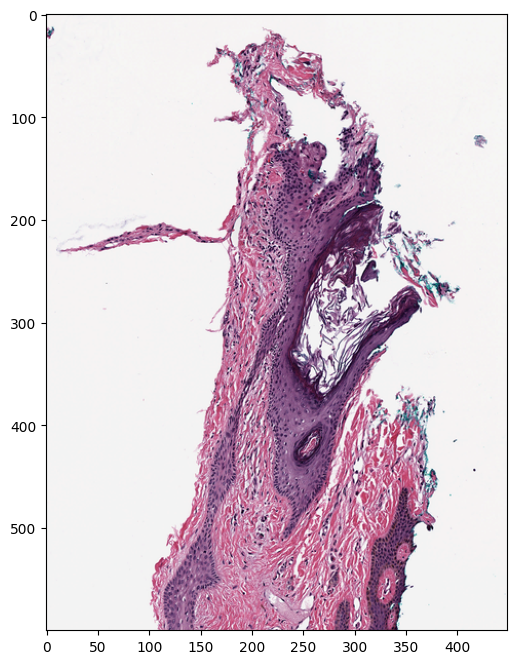

In [ ]:
wsi_thumbnail = wsi.get_thumbnail(size = (600,600))
wsi_thumbnail.show()

wsi_thumbnail_np = np.array(wsi_thumbnail)
plt.figure(figsize=(8,8))
plt.imshow(wsi_thumbnail_np)

In [ ]:
# Getting slide dimensions at each pyramidial level
# This image only contains one level


dimensions = wsi.dimensions

# Counting the number of levels this pyramidial image has

num_levels = len(dimensions)

print("Number of levels in this image are:", num_levels)

print("Dimensions of various levels in this image are:", dimensions)


Number of levels in this image are: 2
Dimensions of various levels in this image are: (2220, 2967)


In [ ]:
# Checking how much this levels are downsampled from the original image

factors = wsi.level_downsamples
print(factors)

(1.0,)


In [ ]:
# Splitting our WSI into tiles

from openslide.deepzoom import DeepZoomGenerator

tiles = DeepZoomGenerator(wsi, tile_size=256, overlap=0, limit_bounds= False)



In [ ]:
# The deepzoom generator splits our WSI into many levels

# Checking the number of levels deepzoom generated



print("The number of levels in the tiles object are:", tiles.level_count)

The number of levels in the tiles object are: 13


In [ ]:
# Printing out the dimensions for each level

print(" The dimensions of data in each level are:",tiles.level_dimensions)

 The dimensions of data in each level are: ((1, 1), (2, 2), (3, 3), (5, 6), (9, 12), (18, 24), (35, 47), (70, 93), (139, 186), (278, 371), (555, 742), (1110, 1484), (2220, 2967))


In [ ]:
# Printing the total number of tiles at each level

print("Total number of tiles at each level =:", tiles.tile_count)

Total number of tiles at each level =: 160


In [ ]:
# Number of tiles at a specific level

level_num = 11


print("Tile shape at level", level_num, "is:", tiles.level_tiles[level_num])

Tile shape at level 11 is: (5, 6)


In [ ]:
print("This means there are ", tiles.level_tiles[level_num][0]*tiles.level_tiles[level_num][1], " total tiles in this level")

This means there are  30  total tiles in this level


In [ ]:
tile_dims = tiles.get_tile_dimensions(11,(3,5))

tile_dims

(256, 204)

In [ ]:
single_tile = tiles.get_tile(12,(3,10))

single_tile_RGB = single_tile.convert('RGB')
single_tile_RGB.show()

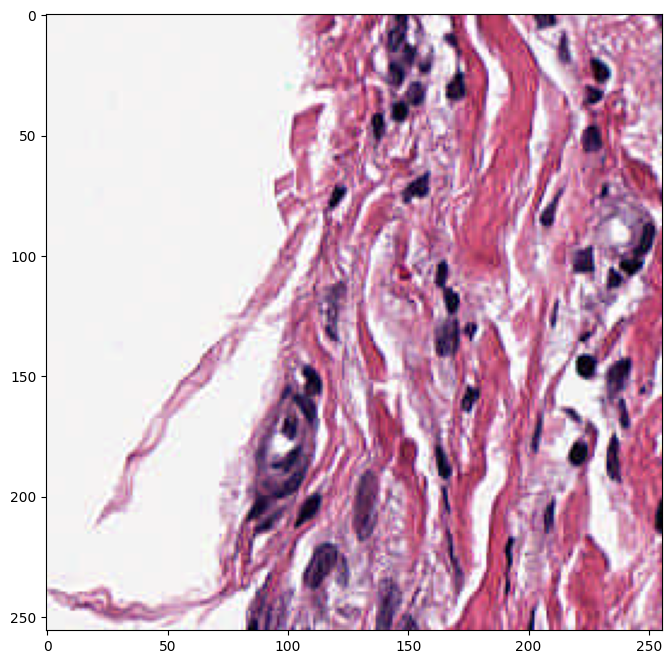

In [ ]:
plt.figure(figsize=(8,8))
plt.imshow(single_tile_RGB)


In [ ]:
wsi_thumbnail_np = np.array(wsi_thumbnail)
plt.figure(figsize=(8,8))
plt.imshow(wsi_thumbnail_np)